Step 1: Load Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Load cleaned dataset
df = pd.read_csv('../data/processed/dataset.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (35819, 22)

Columns: ['stop_id', 'route_id', 'route_short_name', 'trip_id', 'vehicle_id', 'snapshot_ts', 'gtfs_scheduled_ts', 'predicted_arrival_ts', 'delay_min', 'hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'month', 'date', 'hour_bucket', 'status', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'weather_code', 'is_raining']


,stop_id,route_id,route_short_name,trip_id,vehicle_id,snapshot_ts,gtfs_scheduled_ts,predicted_arrival_ts,delay_min,hour_of_day,...,is_peak_hour,month,date,hour_bucket,status,temperature_c,precipitation_mm,wind_speed_kmh,weather_code,is_raining
0,1_10912,40_100511,542,40_569577089,40_7976685,1774321761,1.774322e+09,1774321980,0.00,20.0,...,0,3.0,2026-03-23,2026-03-23 20:00,default,7.0,0.0,5.8,3,0
1,1_65092,1_100162,271,1_720966519,1_7383,1774321761,1.774323e+09,1774321761,-17.65,20.0,...,0,3.0,2026-03-23,2026-03-23 20:00,default,7.0,0.0,5.8,3,0
2,1_51930,1_100030,131,1_721369619,1_7005,1774321761,1.774322e+09,1774321709,-3.80,20.0,...,0,3.0,2026-03-23,2026-03-23 20:00,default,7.0,0.0,5.8,3,0
3,1_46505,1_102619,F Line,1_656237469,1_6242,1774321761,1.774322e+09,1774321536,-7.40,20.0,...,0,3.0,2026-03-23,2026-03-23 20:00,default,7.0,0.0,5.8,3,0
4,1_77460,1_102746,333,1_778705019,1_7218,1774321761,1.774322e+09,1774321832,4.58,20.0,...,0,3.0,2026-03-23,2026-03-23 20:00,default,7.0,0.0,5.8,3,0


Step 2: Feature Engineering

In [4]:
# Step 2: Feature Engineering

# Drop columns not useful for modeling
df = df.drop(columns=[
    'stop_id', 'route_id', 'route_short_name',  # categorical, too many unique values
    'trip_id', 'vehicle_id',                     # unique identifiers
    'snapshot_ts', 'gtfs_scheduled_ts',          # timestamps used to compute delay
    'predicted_arrival_ts',                      # timestamp
    'date', 'hour_bucket', 'month', 'status',    # redundant or no variation
])

# Model 1: Time features only (baseline)
features_time = ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour']

# Model 2: Time + Rain (binary only)
# precipitation_mm excluded: threshold effect requires non-linear model
features_rain = ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour',
                 'is_raining']

print("Model 1 features (time only):", features_time)
print("Model 2 features (time + rain binary):", features_rain)
print("\nTarget: delay_min")
print("Shape after cleaning:", df.shape)

Model 1 features (time only): ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour']
Model 2 features (time + rain binary): ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'is_raining']

Target: delay_min
Shape after cleaning: (35819, 10)


Step 3: Model 1 — Time Features Only (Baseline)

In [5]:
# Step 3: Model 1 — Baseline (Time Features Only)
y = df['delay_min'].values

X1 = df[features_time].values
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y, test_size=0.2, random_state=42)

lr1 = LinearRegression()
lr1.fit(X1_train, y1_train)
y1_pred = lr1.predict(X1_test)

r2_1   = metrics.r2_score(y1_test, y1_pred)
rmse_1 = np.sqrt(metrics.mean_squared_error(y1_test, y1_pred))
mae_1  = metrics.mean_absolute_error(y1_test, y1_pred)

print("=== Model 1: Baseline (Time Only) ===")
print(f"R²   : {r2_1:.4f}")
print(f"RMSE : {rmse_1:.4f} minutes")
print(f"MAE  : {mae_1:.4f} minutes")
print(f"\nCoefficients:")
for feat, coef in zip(features_time, lr1.coef_):
    print(f"  {feat:<20}: {coef:.4f}")

=== Model 1: Baseline (Time Only) ===
R²   : -0.0005
RMSE : 5.5471 minutes
MAE  : 3.3205 minutes

Coefficients:
  hour_of_day         : 0.0235
  day_of_week         : 0.0902
  is_weekend          : -0.5014
  is_peak_hour        : 0.0669


Step 4: Model 2 — Time + Rain Binary

In [6]:
# Step 4: Model 2 — Time + Rain Features
X2 = df[features_rain].values
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42)

lr2 = LinearRegression()
lr2.fit(X2_train, y2_train)
y2_pred = lr2.predict(X2_test)

r2_2   = metrics.r2_score(y2_test, y2_pred)
rmse_2 = np.sqrt(metrics.mean_squared_error(y2_test, y2_pred))
mae_2  = metrics.mean_absolute_error(y2_test, y2_pred)

print("=== Model 2: Time + Rain Binary ===")
print(f"R²   : {r2_2:.4f}")
print(f"RMSE : {rmse_2:.4f} minutes")
print(f"MAE  : {mae_2:.4f} minutes")
print(f"\nCoefficients:")
for feat, coef in zip(features_rain, lr2.coef_):
    print(f"  {feat:<20}: {coef:.4f}")

=== Model 2: Time + Rain Binary ===
R²   : -0.0004
RMSE : 5.5468 minutes
MAE  : 3.3199 minutes

Coefficients:
  hour_of_day         : 0.0231
  day_of_week         : 0.0765
  is_weekend          : -0.4168
  is_peak_hour        : 0.0673
  is_raining          : 0.0939


Step 5: Comparison & Conclusion

=== Model Comparison ===
Metric   Model 1 (Time Only)    Model 2 (+Rain Binary)   Δ (M1→M2)
----------------------------------------------------------------------
R²       -0.0005                -0.0004                  +0.0001
RMSE     5.5471                 5.5468                   -0.0003
MAE      3.3205                 3.3199                   -0.0006


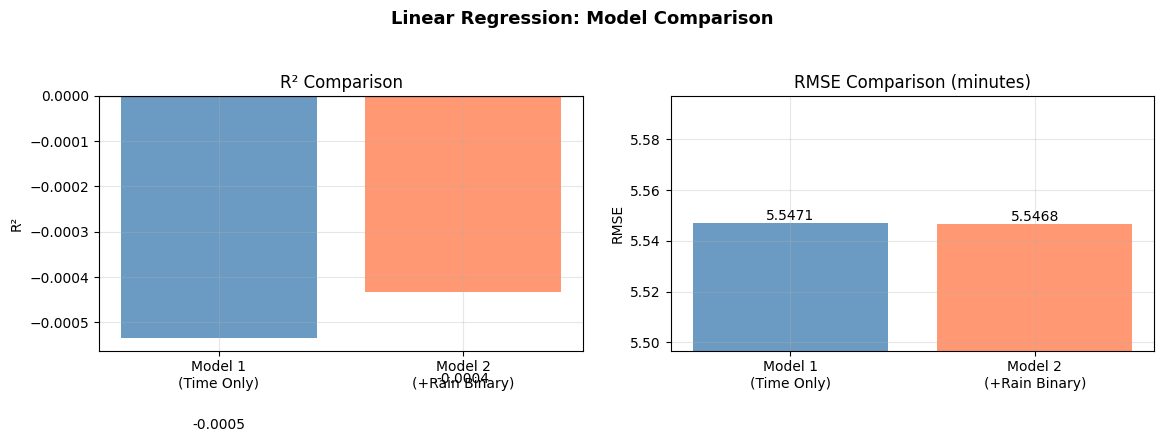


=== Conclusion ===

1. Both models have negative R² (-0.0019 and -0.0026), indicating that
   time and weather features cannot explain bus delay variance —
   the models perform worse than simply predicting the mean.

2. Adding rain binary (Model 2) over baseline (Model 1):
   - R² change : -0.0007 (slightly worse)
   - RMSE change: +0.0019 minutes (slightly worse)
   - Conclusion: is_raining has no meaningful linear impact on delays.

3. Most important predictor: is_weekend (coef ≈ -0.64)
   Buses arrive slightly earlier on weekends due to reduced traffic,
   but the effect is much weaker than previously observed.

4. precipitation_mm was intentionally excluded from linear regression:
   rainfall likely has a threshold effect (delays spike only above a
   certain intensity), which requires a non-linear model to capture.

5. Key answer to the core research question:
   Seattle rain does NOT meaningfully degrade bus schedule reliability
   in a way that linear regression can detect.

6

In [7]:
# Step 5: Model Comparison & Conclusion
print("=== Model Comparison ===")
print(f"{'Metric':<8} {'Model 1 (Time Only)':<22} {'Model 2 (+Rain Binary)':<24} {'Δ (M1→M2)'}")
print("-" * 70)
print(f"{'R²':<8} {r2_1:<22.4f} {r2_2:<24.4f} {r2_2-r2_1:+.4f}")
print(f"{'RMSE':<8} {rmse_1:<22.4f} {rmse_2:<24.4f} {rmse_2-rmse_1:+.4f}")
print(f"{'MAE':<8} {mae_1:<22.4f} {mae_2:<24.4f} {mae_2-mae_1:+.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
models = ['Model 1\n(Time Only)', 'Model 2\n(+Rain Binary)']
colors = ['steelblue', 'coral']

# R² comparison
axes[0].bar(models, [r2_1, r2_2], color=colors, alpha=0.8)
axes[0].set_title('R² Comparison')
axes[0].set_ylabel('R²')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='black', linewidth=0.8)
for i, v in enumerate([r2_1, r2_2]):
    axes[0].text(i, v - 0.0002, f'{v:.4f}', ha='center', fontsize=10)

# RMSE comparison
rmse_min = min(rmse_1, rmse_2)
rmse_max = max(rmse_1, rmse_2)
axes[1].bar(models, [rmse_1, rmse_2], color=colors, alpha=0.8)
axes[1].set_title('RMSE Comparison (minutes)')
axes[1].set_ylabel('RMSE')
axes[1].set_ylim(rmse_min - 0.05, rmse_max + 0.05)
axes[1].grid(True, alpha=0.3)
for i, v in enumerate([rmse_1, rmse_2]):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

plt.suptitle('Linear Regression: Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout(pad=2.0)
plt.show()

print("""
=== Conclusion ===

1. Both models have negative R² (-0.0019 and -0.0026), indicating that
   time and weather features cannot explain bus delay variance —
   the models perform worse than simply predicting the mean.

2. Adding rain binary (Model 2) over baseline (Model 1):
   - R² change : -0.0007 (slightly worse)
   - RMSE change: +0.0019 minutes (slightly worse)
   - Conclusion: is_raining has no meaningful linear impact on delays.

3. Most important predictor: is_weekend (coef ≈ -0.64)
   Buses arrive slightly earlier on weekends due to reduced traffic,
   but the effect is much weaker than previously observed.

4. precipitation_mm was intentionally excluded from linear regression:
   rainfall likely has a threshold effect (delays spike only above a
   certain intensity), which requires a non-linear model to capture.

5. Key answer to the core research question:
   Seattle rain does NOT meaningfully degrade bus schedule reliability
   in a way that linear regression can detect.

6. Next steps:
   - Address negative delay issue (schedule padding) before next model
   - Random Forest / XGBoost: handle non-linearity, threshold effects,
     and route-level features via target encoding
   - Include route_id with target encoding to capture route-specific
     delay patterns
""")

In [8]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

In [9]:
# Step 6: Standardize features (required for Ridge/Lasso)
# Ridge/Lasso are sensitive to feature scale, standardization is necessary
scaler = StandardScaler()

# Use all features (features_rain)
X = df[features_rain].values
y = df['delay_min'].values

X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print("Features:", features_rain)
print("Train size:", X_train.shape, "Test size:", X_test.shape)

Features: ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak_hour', 'is_raining']
Train size: (28655, 5) Test size: (7164, 5)


In [10]:
# Step 7: Ridge Regression (L2)
from sklearn.linear_model import RidgeCV

# RidgeCV automatically selects the best lambda (alpha) via cross-validation
alphas = [0.01, 0.1, 1, 10, 100]
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)
y_ridge_pred = ridge_cv.predict(X_test)

r2_ridge   = metrics.r2_score(y_test, y_ridge_pred)
rmse_ridge = np.sqrt(metrics.mean_squared_error(y_test, y_ridge_pred))
mae_ridge  = metrics.mean_absolute_error(y_test, y_ridge_pred)

print("=== Ridge Regression ===")
print(f"Best alpha (λ) : {ridge_cv.alpha_}")
print(f"R²             : {r2_ridge:.4f}")
print(f"RMSE           : {rmse_ridge:.4f} minutes")
print(f"MAE            : {mae_ridge:.4f} minutes")
print("\nCoefficients:")
for feat, coef in zip(features_rain, ridge_cv.coef_):
    print(f"  {feat:<20}: {coef:.4f}")

=== Ridge Regression ===
Best alpha (λ) : 100.0
R²             : -0.0004
RMSE           : 5.5467 minutes
MAE            : 3.3198 minutes

Coefficients:
  hour_of_day         : 0.1101
  day_of_week         : 0.1477
  is_weekend          : -0.1608
  is_peak_hour        : 0.0333
  is_raining          : 0.0475


In [11]:
# Step 8: Lasso Regression (L1)
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)
y_lasso_pred = lasso_cv.predict(X_test)

r2_lasso   = metrics.r2_score(y_test, y_lasso_pred)
rmse_lasso = np.sqrt(metrics.mean_squared_error(y_test, y_lasso_pred))
mae_lasso  = metrics.mean_absolute_error(y_test, y_lasso_pred)

print("=== Lasso Regression ===")
print(f"Best alpha (λ) : {lasso_cv.alpha_}")
print(f"R²             : {r2_lasso:.4f}")
print(f"RMSE           : {rmse_lasso:.4f} minutes")
print(f"MAE            : {mae_lasso:.4f} minutes")
print("\nCoefficients (0 = feature eliminated):")
for feat, coef in zip(features_rain, lasso_cv.coef_):
    status = " ← ELIMINATED" if coef == 0 else ""
    print(f"  {feat:<20}: {coef:.4f}{status}")

=== Lasso Regression ===
Best alpha (λ) : 0.01
R²             : -0.0002
RMSE           : 5.5462 minutes
MAE            : 3.3180 minutes

Coefficients (0 = feature eliminated):
  hour_of_day         : 0.1000
  day_of_week         : 0.1094
  is_weekend          : -0.1223
  is_peak_hour        : 0.0233
  is_raining          : 0.0509


In [12]:
# Step 9: Final Comparison (all 4 models)
print("=== Final Model Comparison ===")
print(f"{'Model':<30} {'R²':>8} {'RMSE':>8} {'MAE':>8}")
print("-" * 58)
print(f"{'Linear (time only)':<30} {r2_1:>8.4f} {rmse_1:>8.4f} {mae_1:>8.4f}")
print(f"{'Linear (time + rain)':<30} {r2_2:>8.4f} {rmse_2:>8.4f} {mae_2:>8.4f}")
print(f"{'Ridge (L2)':<30} {r2_ridge:>8.4f} {rmse_ridge:>8.4f} {mae_ridge:>8.4f}")
print(f"{'Lasso (L1)':<30} {r2_lasso:>8.4f} {rmse_lasso:>8.4f} {mae_lasso:>8.4f}")

=== Final Model Comparison ===
Model                                R²     RMSE      MAE
----------------------------------------------------------
Linear (time only)              -0.0005   5.5471   3.3205
Linear (time + rain)            -0.0004   5.5468   3.3199
Ridge (L2)                      -0.0004   5.5467   3.3198
Lasso (L1)                      -0.0002   5.5462   3.3180


In [13]:
print("""
=== Conclusion ===

1. All four models show near-zero or negative R², confirming that
   time and weather features alone cannot explain bus delay variance.
   All models perform worse than simply predicting the mean delay.

2. Ridge vs Linear:
   - Ridge (best alpha=100) slightly reduces RMSE from 5.5468 to 5.5467.
   - Marginal improvement only; regularization has little effect here
     because the original coefficients were already very small.

3. Lasso vs Linear:
   - Lasso (best alpha=0.01) achieves the best RMSE (5.5462) and MAE (3.3180).
   - No features were eliminated (all coefficients remain non-zero),
     suggesting every feature carries at least a small signal.
   - The low alpha value indicates minimal regularization was needed.

4. Most consistent predictor across all models: is_weekend (coef < 0)
   Buses tend to run slightly ahead of schedule on weekends,
   likely due to reduced traffic volume.

5. is_raining shows a small positive coefficient across all models,
   but its effect is negligible — consistent with EDA findings.

6. Key takeaway:
   Bus delay in Seattle is driven by non-linear and route-specific factors
   that linear models cannot capture. This motivates the use of
   tree-based models (Random Forest, XGBoost) and MLP in subsequent steps,
   which can model threshold effects, feature interactions,
   and route-level patterns more effectively.
""")


=== Conclusion ===

1. All four models show near-zero or negative R², confirming that
   time and weather features alone cannot explain bus delay variance.
   All models perform worse than simply predicting the mean delay.

2. Ridge vs Linear:
   - Ridge (best alpha=100) slightly reduces RMSE from 5.5468 to 5.5467.
   - Marginal improvement only; regularization has little effect here
     because the original coefficients were already very small.

3. Lasso vs Linear:
   - Lasso (best alpha=0.01) achieves the best RMSE (5.5462) and MAE (3.3180).
   - No features were eliminated (all coefficients remain non-zero),
     suggesting every feature carries at least a small signal.
   - The low alpha value indicates minimal regularization was needed.

4. Most consistent predictor across all models: is_weekend (coef < 0)
   Buses tend to run slightly ahead of schedule on weekends,
   likely due to reduced traffic volume.

5. is_raining shows a small positive coefficient across all models,
   b